In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.linalg import lu

In [6]:
df = pd.read_excel('/content/linear_algebra_student_dataset.xlsx')

In [7]:
df.head()

,Student_ID,Math,Science,English,Computer,Statistics
0,S1,78,85,74,90,82
1,S2,65,70,68,72,66
2,S3,88,92,81,95,90
3,S4,56,60,58,62,59
4,S5,91,89,84,96,93


In [8]:
df.tail()

,Student_ID,Math,Science,English,Computer,Statistics
45,S46,65,69,66,72,68
46,S47,91,94,90,97,93
47,S48,58,61,59,64,60
48,S49,80,82,78,85,81
49,S50,72,75,73,79,76


In [9]:
df.shape

(50, 6)

In [10]:
df.columns

Index(['Student_ID', 'Math', 'Science', 'English', 'Computer', 'Statistics'], dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Student_ID  50 non-null     object
 1   Math        50 non-null     int64 
 2   Science     50 non-null     int64 
 3   English     50 non-null     int64 
 4   Computer    50 non-null     int64 
 5   Statistics  50 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 2.5+ KB


In [17]:
df.describe()

,Math,Science,English,Computer,Statistics
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,73.92000,77.400000,73.440000,80.240000,76.360000
std,13.77048,13.248026,12.358852,13.405086,13.215266
min,49.00000,55.000000,52.000000,58.000000,54.000000
25%,62.25000,66.250000,63.250000,69.000000,65.250000
50%,73.50000,76.500000,73.000000,79.500000,76.500000
75%,86.75000,89.000000,83.750000,92.750000,88.750000
max,96.00000,99.000000,95.000000,100.000000,98.000000


The subject columns were converted into a matrix form. Each row represents a student, while each column represents a subject. This matrix acts as the foundation for all linear algebra operations performed in the project.

In [18]:
subjects = ['Math', 'Science', 'English', 'Computer', 'Statistics']

A = df[subjects].values

print("Matrix A:")
print(A)

print("\nMatrix Shape:")
print(A.shape)

Matrix A:
[[ 78  85  74  90  82]
 [ 65  70  68  72  66]
 [ 88  92  81  95  90]
 [ 56  60  58  62  59]
 [ 91  89  84  96  93]
 [ 73  77  71  79  75]
 [ 82  86  80  88  84]
 [ 49  55  52  58  54]
 [ 95  97  93  99  96]
 [ 67  69  65  70  68]
 [ 74  76  73  80  77]
 [ 85  88  83  91  87]
 [ 58  62  60  64  61]
 [ 90  94  89  97  92]
 [ 71  75  70  78  74]
 [ 63  67  64  69  66]
 [ 87  90  85  93  89]
 [ 54  59  57  61  58]
 [ 92  95  91  98  94]
 [ 69  72  67  74  70]
 [ 76  81  78  84  80]
 [ 61  65  62  68  64]
 [ 89  91  86  94  90]
 [ 57  60  56  63  59]
 [ 84  87  82  89  85]
 [ 66  71  69  73  70]
 [ 93  96  92  99  95]
 [ 52  57  54  60  56]
 [ 79  83  77  86  81]
 [ 64  68  66  71  67]
 [ 86  89  84  92  88]
 [ 55  58  53  61  57]
 [ 94  98  95 100  97]
 [ 68  73  70  76  72]
 [ 81  84  79  87  83]
 [ 59  63  61  65  62]
 [ 90  93  88  96  91]
 [ 62  66  63  69  65]
 [ 77  80  76  83  79]
 [ 53  56  55  59  57]
 [ 88  90  87  94  89]
 [ 70  74  71  77  73]
 [ 96  99  94 100  98]
 

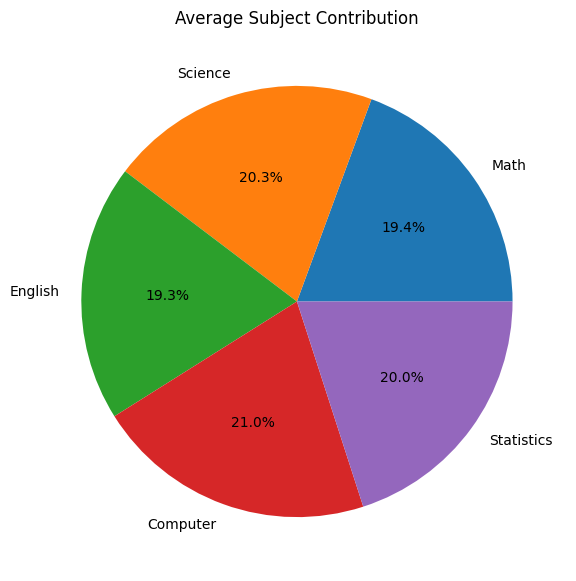

In [51]:
subjects = ['Math', 'Science', 'English', 'Computer', 'Statistics']

avg_marks = df[subjects].mean()

plt.figure(figsize=(7,7))

plt.pie(
    avg_marks,
    labels=subjects,
    autopct='%1.1f%%'
)

plt.title("Average Subject Contribution")

plt.show()

Each student’s marks were represented as a vector. For example, one student’s marks in all subjects form a numerical vector that can be used for mathematical computations such as norms and dot products.

In [19]:
student1 = A[0]

print("Student 1 Vector:")
print(student1)

Student 1 Vector:
[78 85 74 90 82]


he L1 norm and L2 norm of the student vectors were calculated. These norms measure the magnitude or length of the vectors. The results indicate the overall academic strength of individual students.


In [20]:
L1_norm = np.linalg.norm(student1, 1)

L2_norm = np.linalg.norm(student1, 2)

print("L1 Norm:", L1_norm)
print("L2 Norm:", L2_norm)

L1 Norm: 409.0
L2 Norm: 183.3275756671647


The dot product between two student vectors was computed to measure similarity in their academic performance. A larger dot product value indicates stronger similarity between students.

In [21]:
student2 = A[1]

dot_product = np.dot(student1, student2)

print("Dot Product:")
print(dot_product)

Dot Product:
27944


The angle between two student vectors was calculated using cosine similarity. Smaller angles indicate more similar performance patterns between students, while larger angles indicate differences in subject performance.

In [22]:
cos_theta = np.dot(student1, student2) / (
    np.linalg.norm(student1) * np.linalg.norm(student2)
)

angle = np.arccos(cos_theta)

angle_degree = np.degrees(angle)

print("Angle in Degrees:")
print(angle_degree)

Angle in Degrees:
2.7887706491567683


The cross product was calculated using marks from three subjects. This operation demonstrates vector orientation and orthogonality in three-dimensional space.

In [23]:
a = student1[:3]
b = student2[:3]

cross_product = np.cross(a, b)

print("Cross Product:")
print(cross_product)

Cross Product:
[ 600 -494  -65]


One student vector was projected onto another vector to measure directional similarity. This projection helps understand how closely one student’s performance aligns with another student.

In [24]:
projection = (
    np.dot(student1, student2)
    / np.dot(student2, student2)
) * student2

print("Projection Vector:")
print(projection)

Projection Vector:
[77.99218515 83.99158401 81.59182447 86.39134355 79.19206492]


The transpose of the student matrix was calculated by converting rows into columns and columns into rows. This operation is useful in covariance calculations and matrix multiplication.

In [25]:
transpose_matrix = A.T

print("Transpose Matrix:")
print(transpose_matrix)

Transpose Matrix:
[[ 78  65  88  56  91  73  82  49  95  67  74  85  58  90  71  63  87  54
   92  69  76  61  89  57  84  66  93  52  79  64  86  55  94  68  81  59
   90  62  77  53  88  70  96  60  83  65  91  58  80  72]
 [ 85  70  92  60  89  77  86  55  97  69  76  88  62  94  75  67  90  59
   95  72  81  65  91  60  87  71  96  57  83  68  89  58  98  73  84  63
   93  66  80  56  90  74  99  64  85  69  94  61  82  75]
 [ 74  68  81  58  84  71  80  52  93  65  73  83  60  89  70  64  85  57
   91  67  78  62  86  56  82  69  92  54  77  66  84  53  95  70  79  61
   88  63  76  55  87  71  94  62  81  66  90  59  78  73]
 [ 90  72  95  62  96  79  88  58  99  70  80  91  64  97  78  69  93  61
   98  74  84  68  94  63  89  73  99  60  86  71  92  61 100  76  87  65
   96  69  83  59  94  77 100  67  88  72  97  64  85  79]
 [ 82  66  90  59  93  75  84  54  96  68  77  87  61  92  74  66  89  58
   94  70  80  64  90  59  85  70  95  56  81  67  88  57  97  72  83  62
   91 

Matrix multiplication was performed to analyze relationships between student vectors. The resulting matrix represents interactions and similarities among students.

In [26]:
matrix_mult = np.dot(A, A.T)

print("Matrix Multiplication:")
print(matrix_mult)

Matrix Multiplication:
[[33609 27944 36608 ... 24755 33274 30735]
 [27944 23289 30448 ... 20620 27710 25598]
 [36608 30448 39894 ... 26975 36267 33494]
 ...
 [24755 20620 26975 ... 18262 24544 22674]
 [33274 27710 36267 ... 24544 32994 30475]
 [30735 25598 33494 ... 22674 30475 28155]]


In [27]:
B = np.array([
    [1,2],
    [3,4]
])

print("Matrix B:")
print(B)

Matrix B:
[[1 2]
 [3 4]]


In [28]:
det = np.linalg.det(B)

print("Determinant:")
print(det)

Determinant:
-2.0000000000000004


The determinant and inverse of a square matrix were computed. The determinant indicates whether the matrix is invertible, while the inverse matrix is useful in solving linear systems.

In [29]:
B = np.array([
    [1,2],
    [3,4]
])
inverse = np.linalg.inv(B)

print("Inverse Matrix:")
print(inverse)

Inverse Matrix:
[[-2.   1. ]
 [ 1.5 -0.5]]


The covariance matrix was generated to study relationships between subjects. Positive covariance values indicate that subjects increase together, while negative values indicate opposite trends.

In [30]:
cov_matrix = np.cov(A.T)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[189.62612245 181.68571429 168.48489796 183.75428571 181.58040816]
 [181.68571429 175.51020408 162.24897959 177.16734694 174.48571429]
 [168.48489796 162.24897959 152.74122449 163.5044898  161.87918367]
 [183.75428571 177.16734694 163.5044898  179.69632653 176.68734694]
 [181.58040816 174.48571429 161.87918367 176.68734694 174.64326531]]


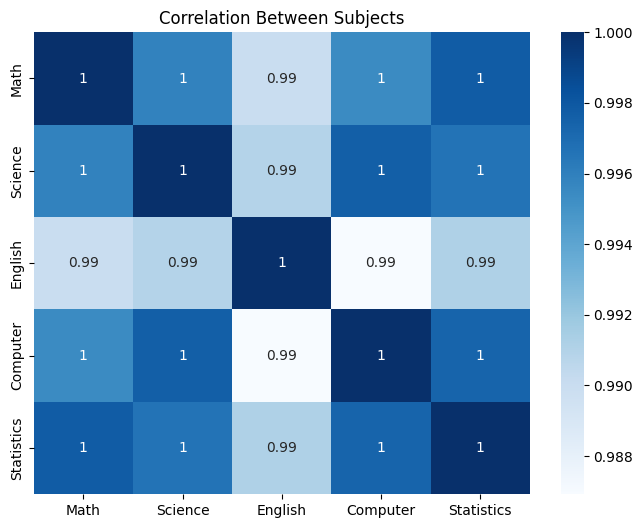

In [32]:
import seaborn as sns

correlation = df[subjects].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Between Subjects")

plt.show()

Eigenvalues and eigenvectors were computed from the covariance matrix. These values identify the principal directions of variance within the dataset and are essential for PCA.

In [33]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[8.68201760e+02 2.40951406e+00 9.42884911e-01 1.98976387e-01
 4.64007229e-01]

Eigenvectors:
[[-0.46657585 -0.13302887  0.72136999 -0.28787444 -0.40170131]
 [-0.44901441 -0.12400045 -0.48770833  0.41503269 -0.61065407]
 [-0.41684537  0.87815813 -0.11840416 -0.17333695  0.10494283]
 [-0.45404476 -0.4248107  -0.40281394 -0.57090493  0.35381876]
 [-0.44808071 -0.12369876  0.25590487  0.6236169   0.57405309]]


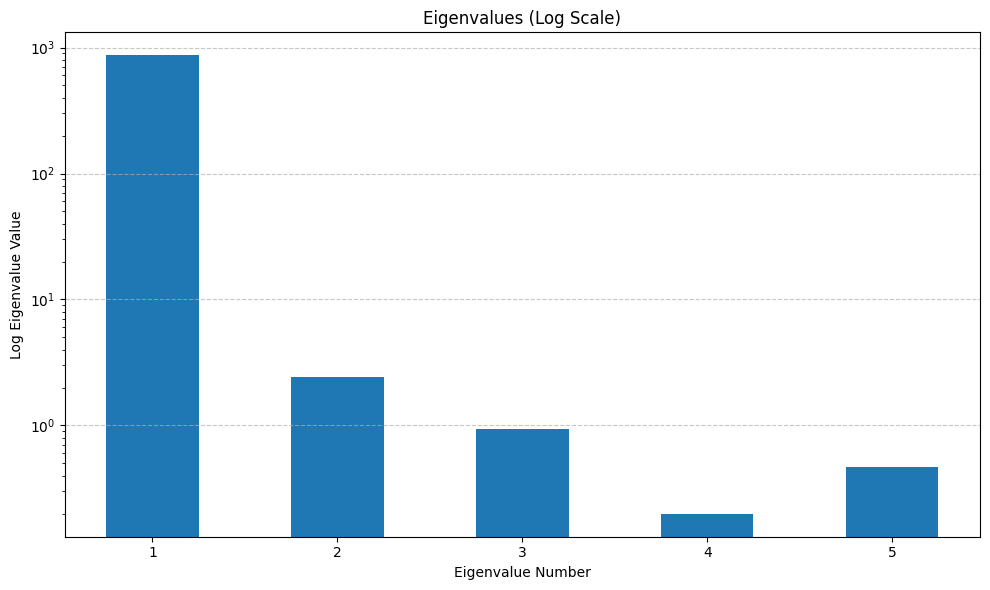

In [34]:
eigen_real = np.real(eigenvalues)

plt.figure(figsize=(10,6))

plt.bar(
    range(1, len(eigen_real)+1),
    eigen_real,
    width=0.5
)

# Log scale
plt.yscale('log')

plt.title("Eigenvalues (Log Scale)")

plt.xlabel("Eigenvalue Number")

plt.ylabel("Log Eigenvalue Value")

plt.xticks(range(1, len(eigen_real)+1))

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

plt.show()

LU decomposition separated the matrix into lower and upper triangular matrices. This technique simplifies matrix computations and helps solve linear equations efficiently.

In [35]:
P, L, U = lu(A)

print("L Matrix:")
print(L)

print("\nU Matrix:")
print(U)

L Matrix:
[[ 1.          0.          0.          0.          0.        ]
 [ 0.94791667  1.          0.          0.          0.        ]
 [ 0.8125     -0.94193548  1.          0.          0.        ]
 [ 0.51041667 -0.92258065  0.09580838  1.          0.        ]
 [ 0.67708333 -0.61290323 -0.17065868  0.94302521  1.        ]
 [ 0.76041667 -0.35483871  0.31886228  0.03285714  0.11427264]
 [ 0.85416667 -0.29677419  0.25149701  0.06386555  0.15612201]
 [ 0.58333333 -0.46451613 -0.11077844  0.74705882  0.20406688]
 [ 0.98958333  0.2        -0.13922156  0.16512605  0.36970558]
 [ 0.69791667  0.01935484  0.07035928 -0.07168067  0.08507204]
 [ 0.77083333  0.06451613 -0.12125749  0.56663866  0.12140413]
 [ 0.88541667 -0.07096774  0.08233533  0.24277311  0.25772178]
 [ 0.60416667 -0.4516129  -0.1257485   0.75394958  0.21336674]
 [ 0.9375     -0.24516129  0.05239521  0.42495798  0.4616441 ]
 [ 0.73958333 -0.36774194  0.19461078  0.3594958   0.08658989]
 [ 0.65625    -0.41935484 -0.0239521   0.5779

SVD decomposed the matrix into three matrices: U, Σ, and Vᵀ. Singular values reveal the importance of each dimension in the dataset.

In [36]:
U, S, VT = np.linalg.svd(A)

print("Singular Values:")
print(S)

Singular Values:
[1224.07515897   11.37947147    9.82126461    5.12867365    3.12286588]


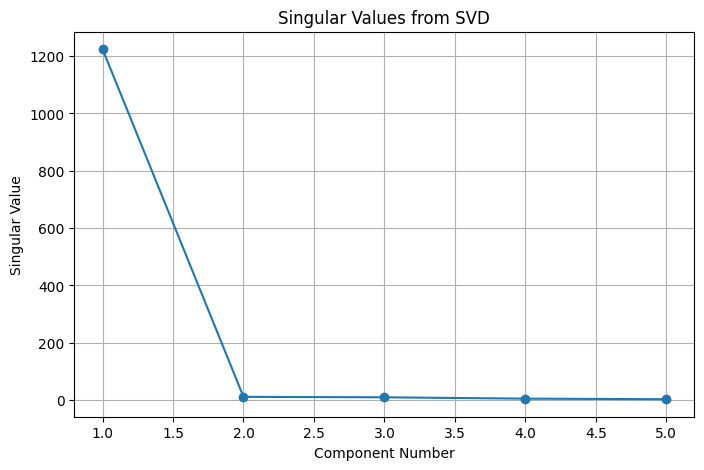

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(S)+1),
    S,
    marker='o'
)

plt.title("Singular Values from SVD")

plt.xlabel("Component Number")

plt.ylabel("Singular Value")

plt.grid()

plt.show()

PCA reduced the dataset from five dimensions to two dimensions while preserving maximum variance. This technique simplifies visualization and reduces computational complexity.

In [37]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(A)

print("PCA Result:")
print(pca_result)

PCA Result:
[[ 1.25082245e+01 -5.83720611e+00]
 [-1.81356471e+01  2.10899997e+00]
 [ 2.90898710e+01 -5.00203465e+00]
 [-3.86704402e+01  8.78681354e-01]
 [ 3.21913783e+01 -3.19055249e+00]
 [-2.79836353e+00 -1.27572351e+00]
 [ 1.73126864e+01 -6.22149395e-01]
 [-5.07391980e+01 -5.21326467e-01]
 [ 4.41077818e+01  1.54322317e+00]
 [-1.89139740e+01 -6.53078200e-02]
 [-5.96905157e-01 -2.00643889e-01]
 [ 2.35673554e+01 -2.80290902e-01]
 [-3.42013179e+01  1.02392005e+00]
 [ 3.60600654e+01  4.12152802e-01]
 [-5.94851489e+00 -1.09131353e+00]
 [-2.34453578e+01  5.08858649e-01]
 [ 2.80364776e+01 -1.35052210e-01]
 [-4.13715771e+01  9.39090875e-01]
 [ 3.96261285e+01  1.10620265e+00]
 [-1.30877478e+01 -8.93690978e-01]
 [ 7.82596664e+00  1.23374766e+00]
 [-2.74604352e+01 -6.11907400e-02]
 [ 3.07376145e+01 -1.95461731e-01]
 [-3.85835103e+01 -1.43547446e+00]
 [ 2.04306688e+01  1.95599211e-01]
 [-1.45568438e+01  1.81052303e+00]
 [ 4.18606896e+01  1.17882199e+00]
 [-4.58034999e+01 -5.09116642e-01]
 [ 1.106

The PCA scatter plot displayed students in a two-dimensional space. Students with similar performance appeared close together, while different performance patterns appeared farther apart.

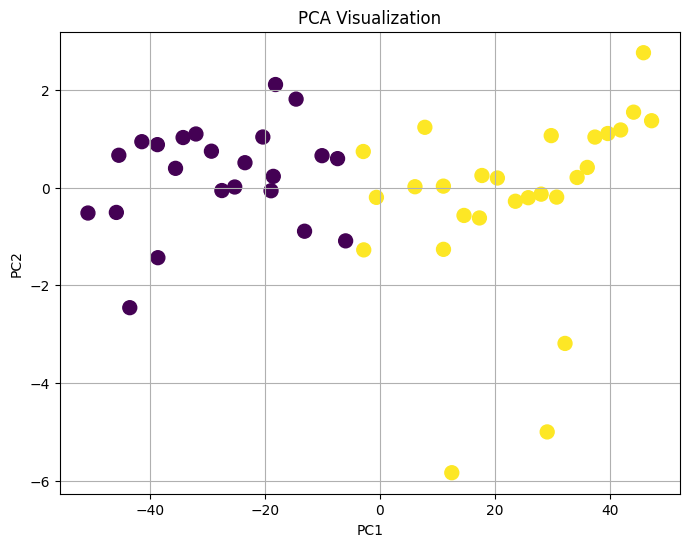

In [39]:
df['Average'] = df[subjects].mean(axis=1)

df['Category'] = np.where(
    df['Average'] >= 75,
    'Above Average',
    'Below Average'
)
labels = df['Category'].map({
    'Above Average':1,
    'Below Average':0
})

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=labels,
    s=100
)

plt.title("PCA Visualization")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid()

plt.show()

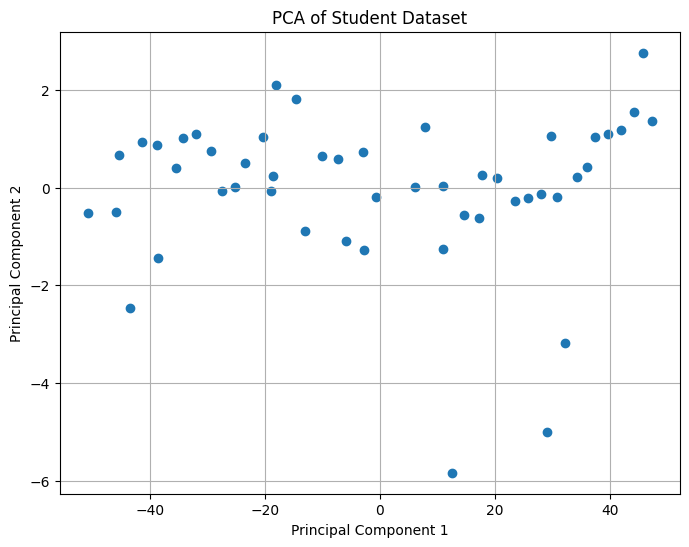

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_result[:,0],
    pca_result[:,1]
)

plt.title("PCA of Student Dataset")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid()

plt.show()

Students were classified into two categories: Above Average and Below Average based on their average marks. These labels were used for supervised classification in LDA.

In [41]:
df['Average'] = df[subjects].mean(axis=1)

df['Category'] = np.where(
    df['Average'] >= 75,
    'Above Average',
    'Below Average'
)

print(df[['Student_ID','Average','Category']].head())

  Student_ID  Average       Category
0         S1     81.8  Above Average
1         S2     68.2  Below Average
2         S3     89.2  Above Average
3         S4     59.0  Below Average
4         S5     90.6  Above Average


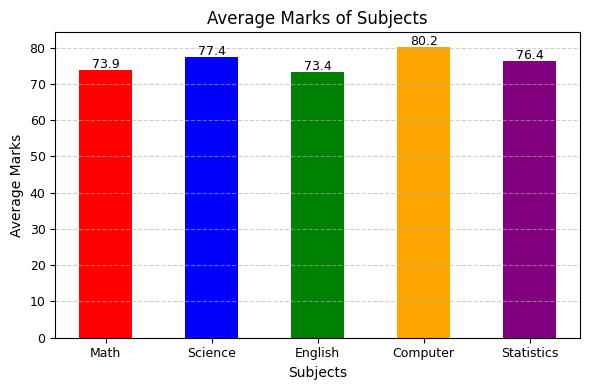

In [42]:
subject_avg = df[subjects].mean()

plt.figure(figsize=(6,4))

bars = plt.bar(
    subject_avg.index,
    subject_avg.values,
    color=['red', 'blue', 'green', 'orange', 'purple'],
    width=0.5
)
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}',
        ha='center',
        fontsize=9
    )

plt.title(
    "Average Marks of Subjects",
    fontsize=12
)

plt.xlabel(
    "Subjects",
    fontsize=10
)

plt.ylabel(
    "Average Marks",
    fontsize=10
)

plt.xticks(fontsize=9)

plt.yticks(fontsize=9)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.show()

Text labels were converted into numerical values to make them compatible with machine learning algorithms. Above Average was encoded as 1 and Below Average as 0.

In [43]:
labels = df['Category'].map({
    'Above Average':1,
    'Below Average':0
})

LDA was applied to maximize separation between the two student categories. This technique identifies the best linear boundary for classification.

In [44]:
lda = LinearDiscriminantAnalysis(
    n_components=1
)

lda_result = lda.fit_transform(
    A,
    labels
)

print("LDA Result:")
print(lda_result)

LDA Result:
[[ 2.33572349]
 [-2.12970991]
 [ 3.03900676]
 [-3.11422557]
 [ 3.88228875]
 [-0.17486375]
 [ 1.18720259]
 [-3.46817582]
 [ 2.75476765]
 [-1.74748324]
 [ 0.32356378]
 [ 1.7943384 ]
 [-2.81154416]
 [ 2.52682963]
 [-0.17197458]
 [-1.91903088]
 [ 2.09701981]
 [-3.26445009]
 [ 2.71791358]
 [-1.06849322]
 [ 0.46556633]
 [-1.95700114]
 [ 2.24724433]
 [-2.57901109]
 [ 1.20161735]
 [-1.44836163]
 [ 2.86925428]
 [-3.16661059]
 [ 0.99789163]
 [-1.63878878]
 [ 1.94567911]
 [-2.74588275]
 [ 2.77253097]
 [-0.74515931]
 [ 1.18897558]
 [-2.66020346]
 [ 2.37437273]
 [-1.80566043]
 [ 0.44780301]
 [-3.2384648 ]
 [ 2.08899527]
 [-0.59493479]
 [ 2.92966385]
 [-2.2441516 ]
 [ 1.20339035]
 [-1.35163832]
 [ 2.56657288]
 [-2.6992899 ]
 [ 0.74936823]
 [ 0.0375295 ]]


The LDA graph displayed the classification of students into Above Average and Below Average groups. Students with similar performance clustered together, while distinct groups appeared separated along the LDA axis. The visualization confirmed that LDA successfully classified students based on academic performance patterns.

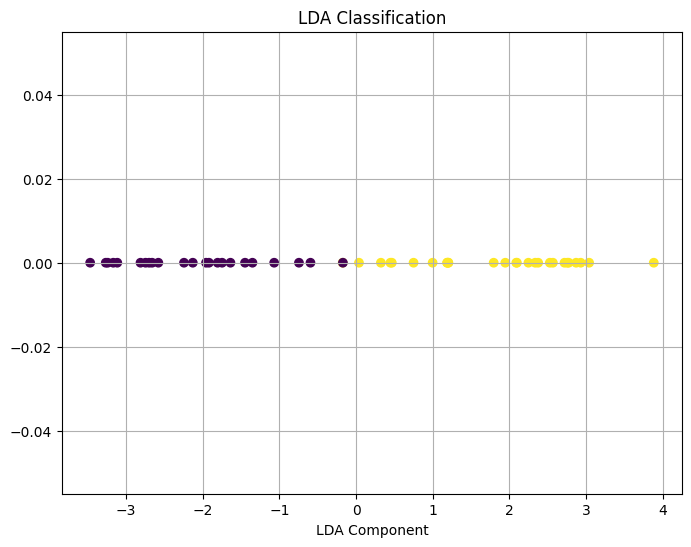

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    lda_result,
    np.zeros_like(lda_result),
    c=labels
)

plt.title("LDA Classification")

plt.xlabel("LDA Component")

plt.grid()

plt.show()

The heatmap visualizes student marks using color intensity, where darker or brighter colors represent higher values and lighter colors represent lower values. It helps identify patterns, similarities, and variations in student performance across different subjects. The heatmap makes it easier to compare subject scores and observe performance trends visuall

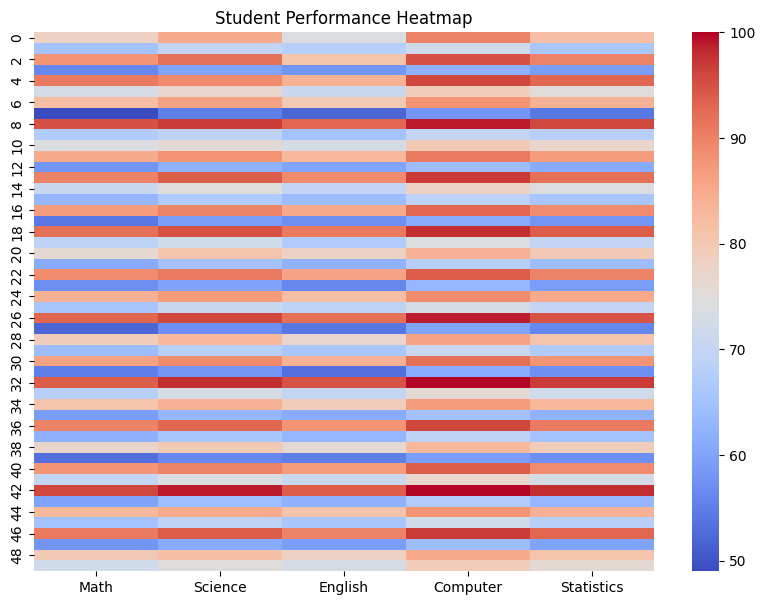

In [46]:
import seaborn as sns

plt.figure(figsize=(10,7))

sns.heatmap(
    df[subjects],
    cmap='coolwarm',
    annot=False
)

plt.title("Student Performance Heatmap")

plt.show()

The box plot represents the distribution and spread of marks for each subject. It shows the median, quartiles, and possible outliers in the dataset. The plot indicates that most students scored within a consistent range, while a few values may appear as outliers. It helps compare the variability and performance distribution across all subjects.

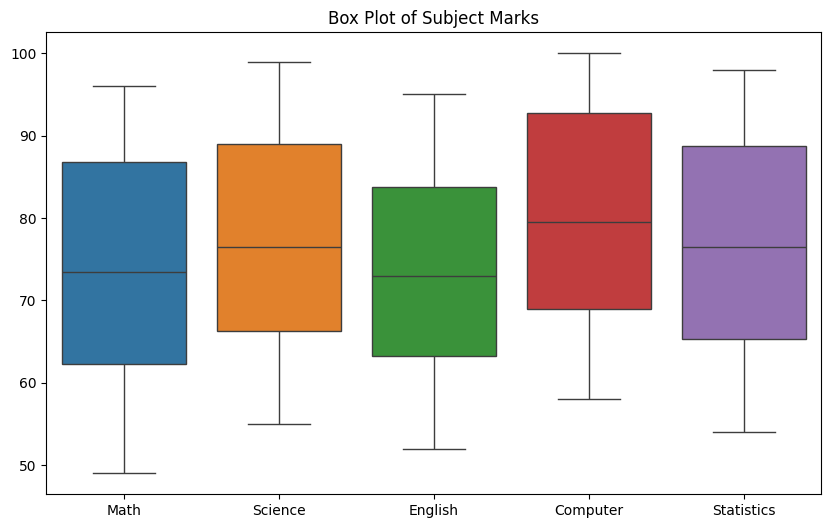

In [48]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[subjects])

plt.title("Box Plot of Subject Marks")

plt.show()

The histogram with KDE shows the distribution of Mathematics marks among students. Most students scored between 65 and 90 marks, indicating good overall performance. The KDE curve provides a smooth representation of the distribution pattern and shows that the data is concentrated around higher marks with few low-scoring students.

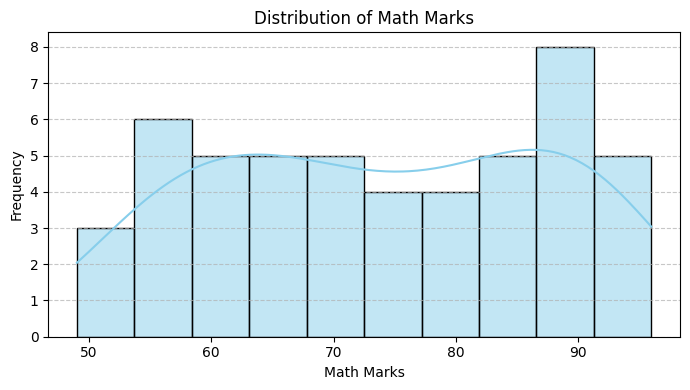

In [53]:
import seaborn as sns

plt.figure(figsize=(7,4))

sns.histplot(
    df['Math'],
    bins=10,
    kde=True,
    color='skyblue',
    edgecolor='black'
)

plt.title("Distribution of Math Marks")

plt.xlabel("Math Marks")

plt.ylabel("Frequency")

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

plt.show()

The 3D plot shows student performance in Mathematics, Science, and English. Each point represents a student in three-dimensional space. Students with similar marks appear closer together, while different performances appear farther apart. The graph indicates a positive relationship among the subjects, as students scoring high in one subject also tend to score high in others.

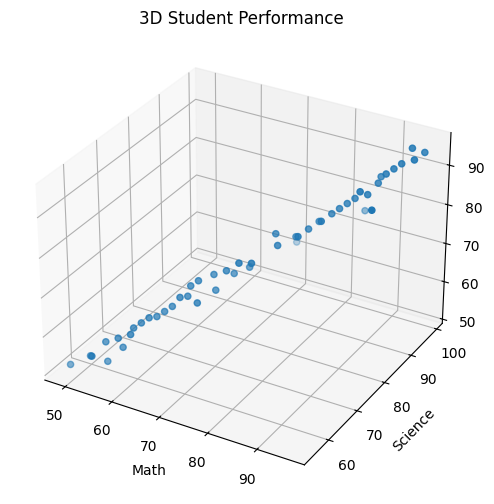

In [49]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Math'],
    df['Science'],
    df['English']
)

ax.set_xlabel('Math')

ax.set_ylabel('Science')

ax.set_zlabel('English')

ax.set_title("3D Student Performance")

plt.show()

This project successfully applied Linear Algebra concepts such as vectors, matrices, eigenvalues, SVD, PCA, and LDA on a student performance dataset. Different visualizations and mathematical operations helped analyze student performance, identify patterns, and classify students effectively. The project demonstrated the importance of Linear Algebra in Data Science, Machine Learning, and data analysis.